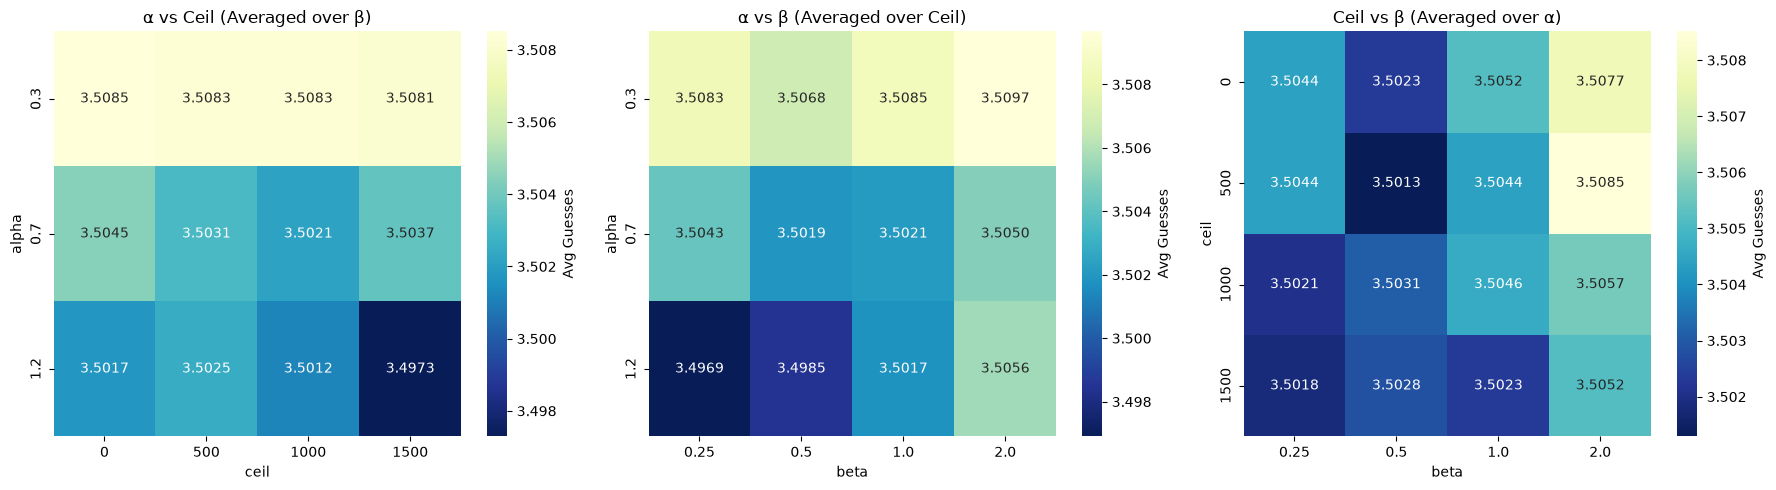

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load grid search output
df_res = pd.read_csv('../data/grid_search_results.csv')

# Exclude baseline (alpha=0) for continuous heatmap visualization
df_sweep = df_res[df_res['alpha'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Alpha vs Ceil
p1 = df_sweep.pivot_table(index='alpha', columns='ceil', values='overall_avg', aggfunc='mean')
sns.heatmap(p1, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=axes[0], cbar_kws={'label': 'Avg Guesses'})
axes[0].set_title('α vs Ceil (Averaged over β)')

# 2. Alpha vs Beta
p2 = df_sweep.pivot_table(index='alpha', columns='beta', values='overall_avg', aggfunc='mean')
sns.heatmap(p2, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=axes[1], cbar_kws={'label': 'Avg Guesses'})
axes[1].set_title('α vs β (Averaged over Ceil)')

# 3. Ceil vs Beta
p3 = df_sweep.pivot_table(index='ceil', columns='beta', values='overall_avg', aggfunc='mean')
sns.heatmap(p3, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=axes[2], cbar_kws={'label': 'Avg Guesses'})
axes[2].set_title('Ceil vs β (Averaged over α)')

plt.tight_layout()
plt.show()

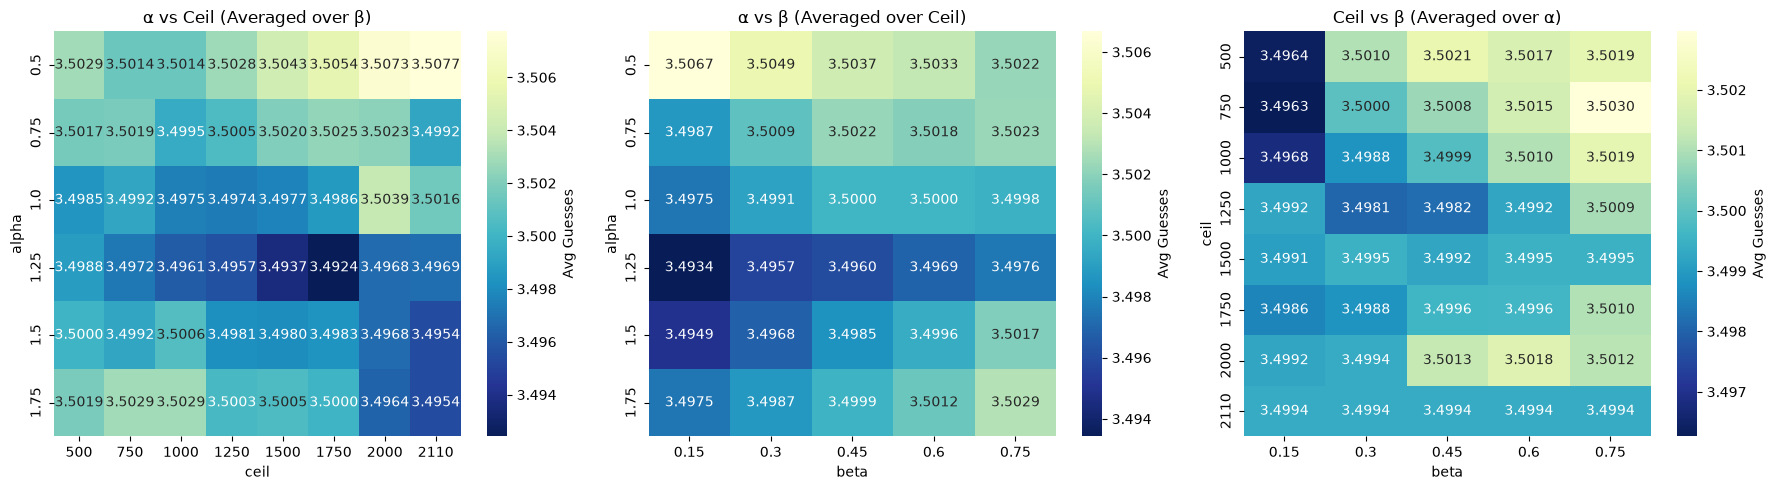

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load grid search output
df_res = pd.read_csv('../data/grid_search_results_2.csv')

# Exclude baseline (alpha=0) for continuous heatmap visualization
df_sweep = df_res[df_res['alpha'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Alpha vs Ceil
p1 = df_sweep.pivot_table(index='alpha', columns='ceil', values='overall_avg', aggfunc='mean')
sns.heatmap(p1, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=axes[0], cbar_kws={'label': 'Avg Guesses'})
axes[0].set_title('α vs Ceil (Averaged over β)')

# 2. Alpha vs Beta
p2 = df_sweep.pivot_table(index='alpha', columns='beta', values='overall_avg', aggfunc='mean')
sns.heatmap(p2, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=axes[1], cbar_kws={'label': 'Avg Guesses'})
axes[1].set_title('α vs β (Averaged over Ceil)')

# 3. Ceil vs Beta
p3 = df_sweep.pivot_table(index='ceil', columns='beta', values='overall_avg', aggfunc='mean')
sns.heatmap(p3, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=axes[2], cbar_kws={'label': 'Avg Guesses'})
axes[2].set_title('Ceil vs β (Averaged over α)')

plt.tight_layout()
plt.show()

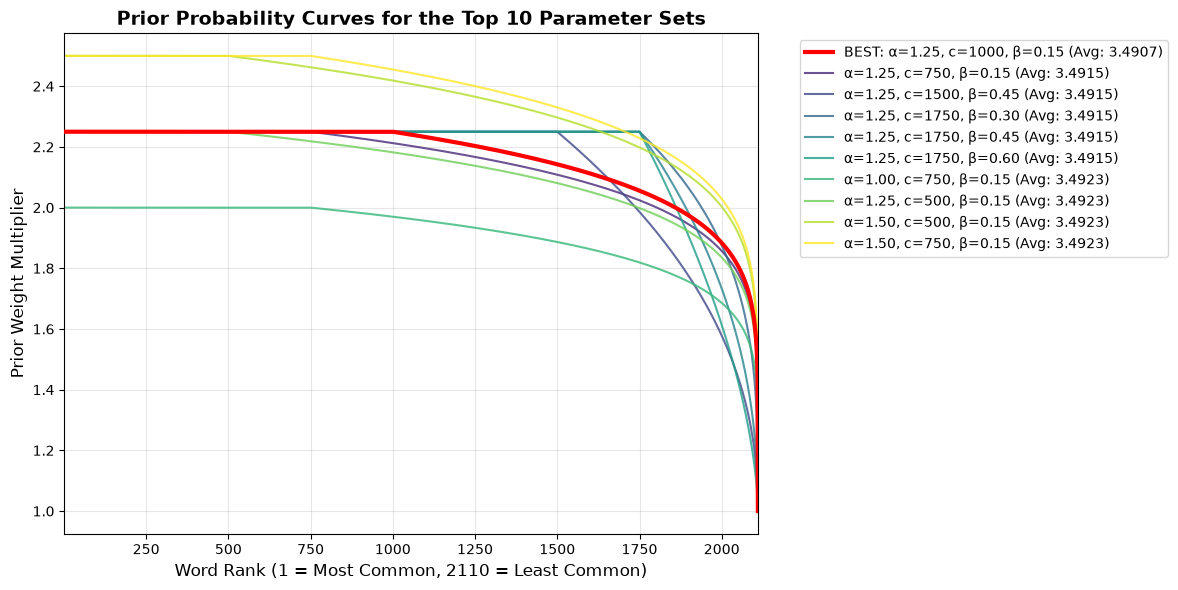

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data
df_res = pd.read_csv('../data/grid_search_results_2.csv')

# 2. Get the top 10 individual parameter combinations overall
top_10 = df_res.nsmallest(10, 'overall_avg')

# 3. Function to mathematically generate the curve
def generate_curve(alpha, ceil, beta, n_top=2110):
    ranks = np.arange(1, n_top + 1)
    priors = np.ones(n_top)
    
    # Ceiling region
    ceil = int(min(ceil, n_top))
    priors[:ceil] = 1.0 + alpha
    
    # Tail decay region
    if ceil < n_top:
        tail_ranks = ranks[ceil:]
        norm_tail_pos = (n_top - tail_ranks) / (n_top - ceil)
        priors[ceil:] = 1.0 + alpha * (norm_tail_pos ** beta)
        
    return ranks, priors

# 4. Plot the curves
plt.figure(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0, 1, 10))
for idx, (i, row) in enumerate(top_10.iterrows()):
    r, p = generate_curve(row['alpha'], row['ceil'], row['beta'])
    label_str = f"α={row['alpha']:.2f}, c={int(row['ceil'])}, β={row['beta']:.2f} (Avg: {row['overall_avg']:.4f})"
    
    # Highlight the absolute best run in red and slightly thicker
    if idx == 0:
        plt.plot(r, p, color='red', linewidth=3, zorder=10, label=f"BEST: {label_str}")
    else:
        plt.plot(r, p, color=colors[idx], linewidth=1.5, alpha=0.8, label=label_str)

plt.title('Prior Probability Curves for the Top 10 Parameter Sets', fontsize=14, fontweight='bold')
plt.xlabel('Word Rank (1 = Most Common, 2110 = Least Common)', fontsize=12)
plt.ylabel('Prior Weight Multiplier', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1, 2110)
plt.tight_layout()
plt.show()

In [6]:
import os
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. PARAMETERS & FILE PATHS
# -----------------------------------------------------------------------------
ALPHA = 1.50            # Peak prior boost
CEIL = 750              # Ceiling threshold for max boost (1.0 + ALPHA)
BETA = 0.15             # Curve shaping exponent

FLOOR_THRESHOLD = 0.004  # Threshold for low priors
FLOOR_REPLACEMENT = 0.0001

input_priors_path = "../data/priors_4500.csv"
output_priors_path = "../data/priors_reweighted.csv"

# -----------------------------------------------------------------------------
# 2. LOAD PRIORS CSV
# -----------------------------------------------------------------------------
print(f"Loading base priors from: {input_priors_path}")
df_temp = pd.read_csv(input_priors_path, header=None)
try:
    float(df_temp.iloc[0, 1])
    df_priors = pd.read_csv(input_priors_path, header=None, names=['word', 'prior'])
except (ValueError, TypeError):
    df_priors = pd.read_csv(input_priors_path)
    df_priors.rename(columns={df_priors.columns[0]: 'word', df_priors.columns[1]: 'prior'}, inplace=True)

df_priors['word'] = df_priors['word'].astype(str).str.lower().str.strip()
df_priors['prior'] = pd.to_numeric(df_priors['prior'], errors='coerce').fillna(0.0)

s_priors = df_priors['prior'].copy()

# -----------------------------------------------------------------------------
# 3. APPLY EXACT CURVE REWEIGHTING FORMULA
# -----------------------------------------------------------------------------
top_mask = np.isclose(s_priors, 1.0)
n_top = int(top_mask.sum())  # 2,110 top-tier words

if n_top > 0 and ALPHA > 0.0:
    ranks = np.arange(1, n_top + 1)
    effective_ceil = min(CEIL, n_top)
    
    priors_top = np.empty(n_top)
    
    # 1. For r <= ceil: P(r) = 1.0 + alpha
    priors_top[:effective_ceil] = 1.0 + ALPHA
    
    # 2. For r > ceil: P(r) = 1.0 + alpha * ((N_top - r) / (N_top - ceil))^beta
    if effective_ceil < n_top:
        tail_ranks = ranks[effective_ceil:]
        norm_tail_pos = (n_top - tail_ranks) / (n_top - effective_ceil)
        priors_top[effective_ceil:] = 1.0 + ALPHA * (norm_tail_pos ** BETA)
        
    s_priors.iloc[np.where(top_mask)[0]] = priors_top

# -----------------------------------------------------------------------------
# 4. APPLY BOTTOM FLOOR THRESHOLD (< 0.004 -> 0.0001)
# -----------------------------------------------------------------------------
floored_mask = s_priors < FLOOR_THRESHOLD
s_priors[floored_mask] = FLOOR_REPLACEMENT

df_priors['reweighted_prior'] = s_priors

# -----------------------------------------------------------------------------
# 5. EXPORT & SUMMARY
# -----------------------------------------------------------------------------
df_export = df_priors[['word', 'reweighted_prior']].copy()
df_export.rename(columns={'reweighted_prior': 'prior'}, inplace=True)
df_export.to_csv(output_priors_path, index=False)

print("=" * 65)
print("--- REWEIGHTED PRIORS SUMMARY ---")
print("=" * 65)
print(f"Top Words Rescaled (N_top):         {n_top:,}")
print(f"Ceiling Words (Max Boost {1.0 + ALPHA:.2f}):    {min(CEIL, n_top):,}")
print(f"Words Floored (< {FLOOR_THRESHOLD} -> {FLOOR_REPLACEMENT}):   {floored_mask.sum():,} ({(floored_mask.sum()/len(df_export)*100):.1f}%)")
print("-" * 65)
print(f"Max Prior Value:                    {df_export['prior'].max():.6f}")
print(f"Min Prior Value:                    {df_export['prior'].min():.6f}")
print(f"\nSuccessfully saved reweighted priors to:\n{output_priors_path}")
print("=" * 65)

Loading base priors from: ../data/priors_4500.csv
--- REWEIGHTED PRIORS SUMMARY ---
Top Words Rescaled (N_top):         2,110
Ceiling Words (Max Boost 2.50):    750
Words Floored (< 0.004 -> 0.0001):   1,518 (33.7%)
-----------------------------------------------------------------
Max Prior Value:                    2.500000
Min Prior Value:                    0.000100

Successfully saved reweighted priors to:
../data/priors_reweighted.csv
